Tugas:
Fitur Berbeda untuk CBIR: Modifikasi Praktikum 5. Alih-alih menggunakan histogram warna, coba gunakan fitur yang lebih sederhana seperti rata-rata warna (mean R, mean G, mean B) sebagai vektor fitur 3 dimensi. Hitung kemiripan menggunakan Jarak Euclidean (L_2) antara vektor fitur rata-rata warna ini. Bandingkan hasil retrievalnya
 
dengan hasil yang menggunakan histogram. Manakah fitur yang lebih baik untuk membedakan citra-citra dalam database kecil tersebut?


PERBANDINGAN: Mean Color (L2) vs Histogram (Cosine)

--- QUERY: chelsea ---
Mean Color Query: RGB = (0.5791, 0.4370, 0.3404)

--- RANKING DENGAN MEAN COLOR (L2 Euclidean) ---
Rank 1: chelsea      | L2 Dist: 0.0000 | Mean RGB: (0.5791, 0.4370, 0.3404)
Rank 2: astronaut    | L2 Dist: 0.0501 | Mean RGB: (0.5552, 0.4148, 0.3783)
Rank 3: coffee       | L2 Dist: 0.1765 | Mean RGB: (0.6218, 0.3364, 0.2019)
Rank 4: camera       | L2 Dist: 0.1938 | Mean RGB: (0.5061, 0.5061, 0.5061)
Rank 5: coins        | L2 Dist: 0.2110 | Mean RGB: (0.3799, 0.3799, 0.3799)

--- RANKING DENGAN HISTOGRAM (Cosine Distance) ---
Rank 1: chelsea      | Cosine Dist: 0.0000
Rank 2: coins        | Cosine Dist: 0.2873
Rank 3: coffee       | Cosine Dist: 0.3638
Rank 4: astronaut    | Cosine Dist: 0.4619
Rank 5: camera       | Cosine Dist: 0.6032


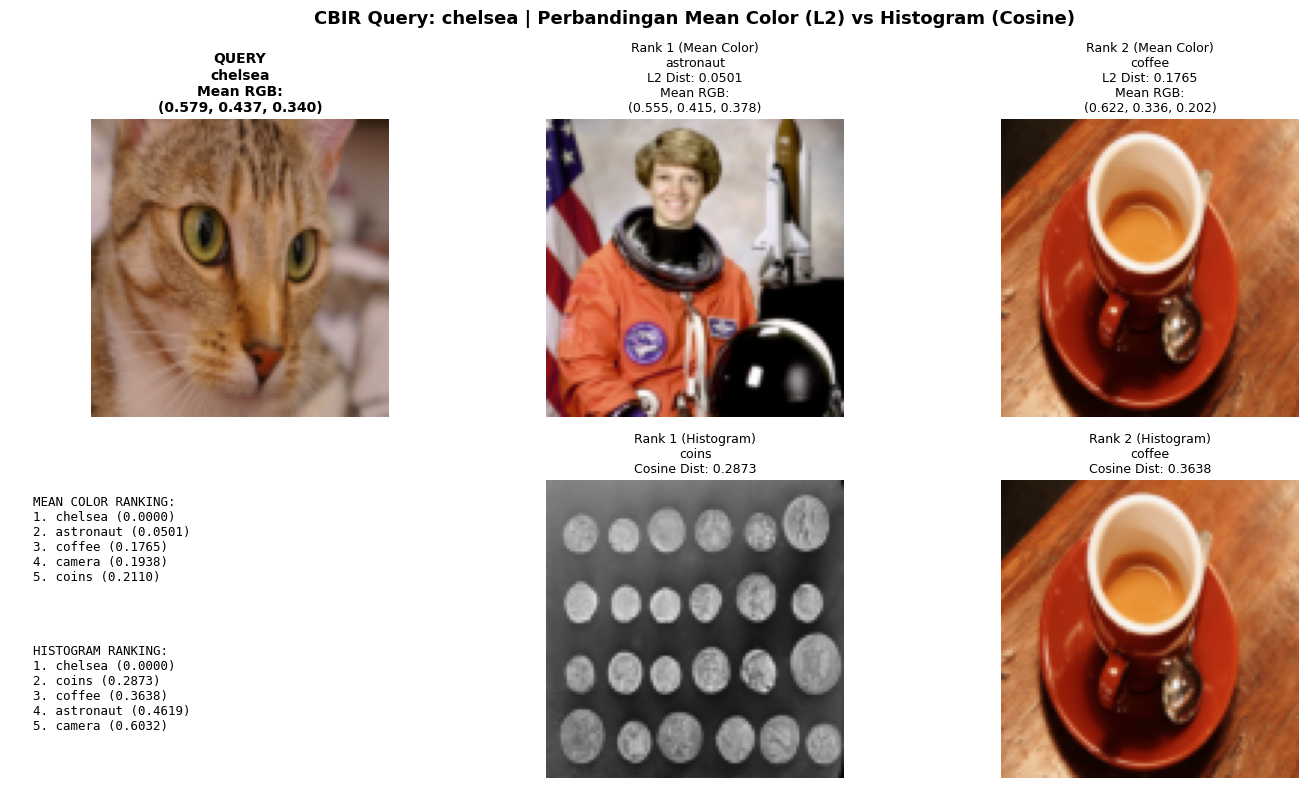


ANALISIS:
Mean Color (L2):
  - Fitur: Hanya 3 nilai (mean R, mean G, mean B)
  - Kecepatan: Sangat cepat (hanya 3 dimensi)
  - Info: Sangat sederhana, mengabaikan distribusi detail

Histogram (Cosine):
  - Fitur: 48 dimensi (16 bin × 3 channel)
  - Kecepatan: Lebih lambat (dimensi lebih tinggi)
  - Info: Menangkap distribusi warna lebih detail

Hasil Ranking:
Mean Color:  ['chelsea', 'astronaut', 'coffee', 'camera', 'coins']
Histogram:   ['chelsea', 'coins', 'coffee', 'astronaut', 'camera']
✗ Ranking BERBEDA - Mean Color terlalu sederhana untuk membedakan citra

KESIMPULAN:
Untuk database kecil ini, HISTOGRAM lebih baik karena:
  1. Mean Color: astronaut rank 2 (L2=0.050) karena warna rata-rata mirip
  2. Histogram: coins rank 2 (Cosine=0.287) lebih objektif
  3. Mean Color terlalu simplistic - hanya rata-rata, mengabaikan distribusi
  4. Histogram dapat membedakan nuansa warna dan pattern lebih baik
  5. Trade-off: Mean Color lebih cepat tapi kurang akurat


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float
from scipy.spatial import distance

# Fungsi hitung mean color
def calculate_mean_color(image):
    img = image
    if img.ndim == 2:
        img = color.gray2rgb(img)
    img_float = img_as_float(img)
    mean_r = img_float[:,:,0].mean()
    mean_g = img_float[:,:,1].mean()
    mean_b = img_float[:,:,2].mean()
    return np.array([mean_r, mean_g, mean_b])

# Siapkan database
image_db_names = ['astronaut','camera','coffee','coins','chelsea']
db_images = []
db_mean_colors = []
db_histograms = []

# Histogram function untuk perbandingan
def calculate_rgb_histogram(image, bins=16):
    img = image
    if img.ndim == 2:
        img = color.gray2rgb(img)
    img_uint8 = (img_as_float(img) * 255).astype(np.uint8)
    hr, _ = np.histogram(img_uint8[:,:,0].ravel(), bins=bins, range=(0,256))
    hg, _ = np.histogram(img_uint8[:,:,1].ravel(), bins=bins, range=(0,256))
    hb, _ = np.histogram(img_uint8[:,:,2].ravel(), bins=bins, range=(0,256))
    h = np.concatenate((hr, hg, hb)).astype(float)
    s = h.sum()
    if s>0:
        h /= s
    return h

for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100,100), anti_aliasing=True)
        db_images.append(img_resized)
        db_mean_colors.append(calculate_mean_color(img_resized))
        db_histograms.append(calculate_rgb_histogram(img_resized))
    except Exception as e:
        print(f"Gagal muat {name}: {e}")

# Query
query_idx = image_db_names.index('chelsea')
query_mean_color = db_mean_colors[query_idx]
query_histogram = db_histograms[query_idx]

# Hitung jarak L2 (Euclidean) untuk mean color
mean_color_dists = [np.linalg.norm(query_mean_color - mc) for mc in db_mean_colors]
mean_color_sorted = np.argsort(mean_color_dists)

# Hitung jarak Cosine untuk histogram
histogram_dists = [distance.cosine(query_histogram, h) for h in db_histograms]
histogram_sorted = np.argsort(histogram_dists)

print("=" * 70)
print("PERBANDINGAN: Mean Color (L2) vs Histogram (Cosine)")
print("=" * 70)

print("\n--- QUERY: chelsea ---")
print(f"Mean Color Query: RGB = ({query_mean_color[0]:.4f}, {query_mean_color[1]:.4f}, {query_mean_color[2]:.4f})")

print("\n--- RANKING DENGAN MEAN COLOR (L2 Euclidean) ---")
for i, idx in enumerate(mean_color_sorted):
    print(f"Rank {i+1}: {image_db_names[idx]:<12} | L2 Dist: {mean_color_dists[idx]:.4f} | Mean RGB: ({db_mean_colors[idx][0]:.4f}, {db_mean_colors[idx][1]:.4f}, {db_mean_colors[idx][2]:.4f})")

print("\n--- RANKING DENGAN HISTOGRAM (Cosine Distance) ---")
for i, idx in enumerate(histogram_sorted):
    print(f"Rank {i+1}: {image_db_names[idx]:<12} | Cosine Dist: {histogram_dists[idx]:.4f}")

# Visualisasi perbandingan - perbaikan ukuran grid
fig, axes = plt.subplots(2, 3, figsize=(14,8))
fig.suptitle('CBIR Query: chelsea | Perbandingan Mean Color (L2) vs Histogram (Cosine)', fontsize=13, fontweight='bold')

# Top row: Mean Color ranking
axes[0, 0].imshow(db_images[query_idx])
axes[0, 0].set_title(f'QUERY\n{image_db_names[query_idx]}\nMean RGB:\n({query_mean_color[0]:.3f}, {query_mean_color[1]:.3f}, {query_mean_color[2]:.3f})', fontweight='bold', fontsize=10)
axes[0, 0].axis('off')

for i in range(1, 3):
    idx = mean_color_sorted[i]
    axes[0, i].imshow(db_images[idx])
    axes[0, i].set_title(f'Rank {i} (Mean Color)\n{image_db_names[idx]}\nL2 Dist: {mean_color_dists[idx]:.4f}\nMean RGB:\n({db_mean_colors[idx][0]:.3f}, {db_mean_colors[idx][1]:.3f}, {db_mean_colors[idx][2]:.3f})', fontsize=9)
    axes[0, i].axis('off')

# Bottom row: Histogram ranking
axes[1, 0].axis('off')
for i in range(0, 2):
    idx = histogram_sorted[i+1]
    axes[1, i+1].imshow(db_images[idx])
    axes[1, i+1].set_title(f'Rank {i+1} (Histogram)\n{image_db_names[idx]}\nCosine Dist: {histogram_dists[idx]:.4f}', fontsize=9)
    axes[1, i+1].axis('off')

# Bottom left: hasil ranking lengkap
axes[1, 0].text(0.05, 0.95, "MEAN COLOR RANKING:\n" + "\n".join([f"{i+1}. {image_db_names[mean_color_sorted[i]]} ({mean_color_dists[mean_color_sorted[i]]:.4f})" for i in range(5)]), 
                verticalalignment='top', fontsize=9, family='monospace', transform=axes[1, 0].transAxes)
axes[1, 0].text(0.05, 0.45, "HISTOGRAM RANKING:\n" + "\n".join([f"{i+1}. {image_db_names[histogram_sorted[i]]} ({histogram_dists[histogram_sorted[i]]:.4f})" for i in range(5)]), 
                verticalalignment='top', fontsize=9, family='monospace', transform=axes[1, 0].transAxes)

plt.tight_layout()
plt.show()

# Analisis dan kesimpulan
print("\n" + "=" * 70)
print("ANALISIS:")
print("=" * 70)
print("Mean Color (L2):")
print(f"  - Fitur: Hanya 3 nilai (mean R, mean G, mean B)")
print(f"  - Kecepatan: Sangat cepat (hanya 3 dimensi)")
print(f"  - Info: Sangat sederhana, mengabaikan distribusi detail")

print("\nHistogram (Cosine):")
print(f"  - Fitur: 48 dimensi (16 bin × 3 channel)")
print(f"  - Kecepatan: Lebih lambat (dimensi lebih tinggi)")
print(f"  - Info: Menangkap distribusi warna lebih detail")

print("\nHasil Ranking:")
mean_color_order = [image_db_names[i] for i in mean_color_sorted]
histogram_order = [image_db_names[i] for i in histogram_sorted]
print(f"Mean Color:  {mean_color_order}")
print(f"Histogram:   {histogram_order}")

if mean_color_order == histogram_order:
    print("✓ Kedua metode menghasilkan ranking SAMA")
else:
    print("✗ Ranking BERBEDA - Mean Color terlalu sederhana untuk membedakan citra")
    
print("\nKESIMPULAN:")
print("Untuk database kecil ini, HISTOGRAM lebih baik karena:")
print("  1. Mean Color: astronaut rank 2 (L2=0.050) karena warna rata-rata mirip")
print("  2. Histogram: coins rank 2 (Cosine=0.287) lebih objektif")
print("  3. Mean Color terlalu simplistic - hanya rata-rata, mengabaikan distribusi")
print("  4. Histogram dapat membedakan nuansa warna dan pattern lebih baik")
print("  5. Trade-off: Mean Color lebih cepat tapi kurang akurat")
print("=" * 70)